**STEP BY STEP APPROACH OF DECISION TREE MODEL**

In [ ]:
import pandas as pd

data = pd.read_csv("train.csv")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Look at data
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# How many percent of data is NULL in each column
for i in data.columns:
  print(f"{i}: {(data[i].isnull().sum() / len(data)) * 100}% is missing")

PassengerId: 0.0% is missing
Survived: 0.0% is missing
Pclass: 0.0% is missing
Name: 0.0% is missing
Sex: 0.0% is missing
Age: 19.865319865319865% is missing
SibSp: 0.0% is missing
Parch: 0.0% is missing
Ticket: 0.0% is missing
Fare: 0.0% is missing
Cabin: 77.10437710437711% is missing
Embarked: 0.22446689113355783% is missing


In [ ]:
# Useless columsn and too many missind data will be dropped

# "PassengerId", "Name", "Ticket" -> Useless, "Cabin" -> too many missing values
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [ ]:
# See results
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [ ]:
# Devide data into X and y
# y - "Survives", X - rest of the data
X = data.drop(columns = ["Survived"])
y = data["Survived"]

X.info()
print("\n")
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   SibSp     891 non-null    int64  
 4   Parch     891 non-null    int64  
 5   Fare      891 non-null    float64
 6   Embarked  889 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 48.9+ KB


<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


In [ ]:
# Split X into train, cv, test
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state = 42)
X_cv, X_test, y_cv, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state = 42)

In [ ]:
# Fill missing places under X_train
median_age = X_train["Age"].median()
freq_embar = X_train["Embarked"].mode()[0]

X_train["Age"] = X_train["Age"].fillna(median_age)
X_cv["Age"] = X_cv["Age"].fillna(median_age)
X_test["Age"] = X_test["Age"].fillna(median_age)

X_train["Embarked"] = X_train["Embarked"].fillna(freq_embar)
X_cv["Embarked"] = X_cv["Embarked"].fillna(freq_embar)
X_test["Embarked"] = X_test["Embarked"].fillna(freq_embar)

# Check
print(X_train.isnull().any(), "\n")
print(X_cv.isnull().any(), "\n")
print(X_test.isnull().any())

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool 

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool 

Pclass      False
Sex         False
Age         False
SibSp       False
Parch       False
Fare        False
Embarked    False
dtype: bool


In [ ]:
# Turn column "Embarked" into tree distinct columns with 0 1 2 instead of C Q S
X_train = pd.get_dummies(X_train, columns=['Embarked'])
X_test = pd.get_dummies(X_test, columns=['Embarked'])
X_cv = pd.get_dummies(X_cv, columns=['Embarked'])

In [ ]:
# Number of columns increased
print(X_train.head())

     Pclass     Sex   Age  SibSp  Parch     Fare  Embarked_C  Embarked_Q  \
570       2    male  62.0      0      0  10.5000       False       False   
787       3    male   8.0      4      1  29.1250       False        True   
74        3    male  32.0      0      0  56.4958       False       False   
113       3  female  20.0      1      0   9.8250       False       False   
635       2  female  28.0      0      0  13.0000       False       False   

     Embarked_S  
570        True  
787       False  
74         True  
113        True  
635        True  


In [ ]:
# Change Sex column's values into 0 and 1 -> male: 0 and female: 1
X_train["Sex"] = X_train["Sex"].map({"male": 0, "female": 1})
X_test["Sex"] = X_test["Sex"].map({"male": 0, "female": 1})
X_cv["Sex"] = X_cv["Sex"].map({"male": 0, "female": 1})

In [ ]:
# Imports
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [ ]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_train_pred = clf.predict(X_train)
y_cv_pred = clf.predict(X_cv)
y_test_pred = clf.predict(X_test)
accuracy_train = accuracy_score(y_train, y_train_pred)
accuracy_cv = accuracy_score(y_cv, y_cv_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f"Accuracy train: {accuracy_train}")
print(f"Accuracy cv: {accuracy_cv}")
print(f"Accuracy test: {accuracy_test}")

Accuracy train: 0.9831460674157303
Accuracy cv: 0.6966292134831461
Accuracy test: 0.7653631284916201


[Text(0.47660648930180183, 0.9722222222222222, 'x[1] <= 0.5\ngini = 0.469\nsamples = 534\nvalue = [333, 201]'),
 Text(0.15732333896396397, 0.9166666666666666, 'x[2] <= 3.5\ngini = 0.29\nsamples = 346\nvalue = [285, 61]'),
 Text(0.3169649141328829, 0.9444444444444444, 'True  '),
 Text(0.02252252252252252, 0.8611111111111112, 'x[3] <= 3.0\ngini = 0.355\nsamples = 13\nvalue = [3, 10]'),
 Text(0.013513513513513514, 0.8055555555555556, 'gini = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.03153153153153153, 0.8055555555555556, 'x[2] <= 2.5\ngini = 0.375\nsamples = 4\nvalue = [3, 1]'),
 Text(0.02252252252252252, 0.75, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.04054054054054054, 0.75, 'gini = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.29212415540540543, 0.8611111111111112, 'x[0] <= 1.5\ngini = 0.259\nsamples = 333\nvalue = [282, 51]'),
 Text(0.06756756756756757, 0.8055555555555556, 'x[5] <= 387.665\ngini = 0.422\nsamples = 66\nvalue = [46, 20]'),
 Text(0.05855855855855856, 0.75, 'x[2

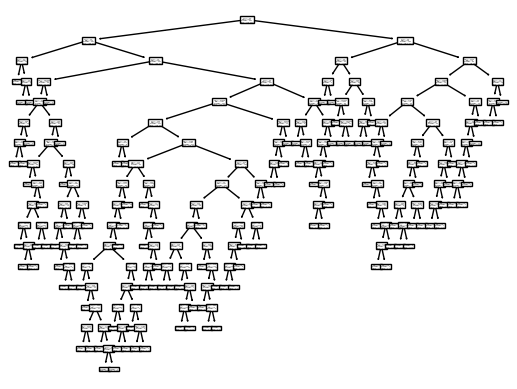

In [ ]:
plot_tree(clf)

In [42]:
# Conclusion on first training
print("Unfortunately we got overfitting -> it is good for learning")
print("\nFirst -> we got realy on trian, but bad on cv and test => Overfitting\n")
print("Second -> we got huge tree -> Overfitting")

Unfortunately we got overfitting -> it is good for learning

First -> we got realy on trian, but bad on cv and test => Overfitting

Second -> we got huge tree -> Overfitting


In [43]:
# Choosing best depth paramenter
depth_list = []
for i in range(1, 21):
  clf_i = DecisionTreeClassifier(max_depth = i, random_state=42)
  clf_i.fit(X_train, y_train)

  y_train_pred = clf_i.predict(X_train)
  y_cv_pred = clf_i.predict(X_cv)

  accuracy_train = accuracy_score(y_train, y_train_pred)
  accuracy_cv = accuracy_score(y_cv, y_cv_pred)

  depth_list.append(accuracy_cv)

  print(f"Depth: {i}  Train: {accuracy_train}   CV: {accuracy_cv}")


Depth: 1  Train: 0.795880149812734   CV: 0.7471910112359551
Depth: 2  Train: 0.8108614232209738   CV: 0.7640449438202247
Depth: 3  Train: 0.8389513108614233   CV: 0.7752808988764045
Depth: 4  Train: 0.846441947565543   CV: 0.7752808988764045
Depth: 5  Train: 0.8726591760299626   CV: 0.7415730337078652
Depth: 6  Train: 0.8951310861423221   CV: 0.7415730337078652
Depth: 7  Train: 0.9138576779026217   CV: 0.7528089887640449
Depth: 8  Train: 0.9232209737827716   CV: 0.7471910112359551
Depth: 9  Train: 0.9344569288389513   CV: 0.7471910112359551
Depth: 10  Train: 0.949438202247191   CV: 0.7415730337078652
Depth: 11  Train: 0.9644194756554307   CV: 0.7191011235955056
Depth: 12  Train: 0.9700374531835206   CV: 0.7191011235955056
Depth: 13  Train: 0.9737827715355806   CV: 0.7191011235955056
Depth: 14  Train: 0.9756554307116105   CV: 0.7078651685393258
Depth: 15  Train: 0.9794007490636704   CV: 0.6966292134831461
Depth: 16  Train: 0.9831460674157303   CV: 0.6966292134831461
Depth: 17  Train: 0.

In [44]:
# Best Depth
print(max(depth_list))
print(depth_list.index(max(depth_list)) + 1)

best_depth = depth_list.index(max(depth_list)) + 1

0.7752808988764045
3


In [45]:
# best for min sample split - min number of elem in order to be allowed to
range_split = [2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 100, 150, 200, 250, 300, 350, 400, 450, 500, 600, 800]

min_smpl_hist = []

for i in range_split:
  clf_sample_i = DecisionTreeClassifier(max_depth = 10, min_samples_split = i, random_state=42)
  clf_sample_i.fit(X_train, y_train)

  y_train_pred = clf_sample_i.predict(X_train)
  y_cv_pred = clf_sample_i.predict(X_cv)

  accuracy_train = accuracy_score(y_train, y_train_pred)
  accuracy_cv = accuracy_score(y_cv, y_cv_pred)

  min_smpl_hist.append(accuracy_cv)

  print(f"Min samples split: {i}  Train: {accuracy_train}   CV: {accuracy_cv}")

Min samples split: 2  Train: 0.949438202247191   CV: 0.7415730337078652
Min samples split: 5  Train: 0.9325842696629213   CV: 0.7303370786516854
Min samples split: 10  Train: 0.9101123595505618   CV: 0.7303370786516854
Min samples split: 15  Train: 0.8782771535580525   CV: 0.7471910112359551
Min samples split: 20  Train: 0.8726591760299626   CV: 0.7528089887640449
Min samples split: 30  Train: 0.8632958801498127   CV: 0.7696629213483146
Min samples split: 40  Train: 0.8595505617977528   CV: 0.7696629213483146
Min samples split: 50  Train: 0.8595505617977528   CV: 0.7696629213483146
Min samples split: 60  Train: 0.8389513108614233   CV: 0.7752808988764045
Min samples split: 70  Train: 0.8352059925093633   CV: 0.7752808988764045
Min samples split: 80  Train: 0.8352059925093633   CV: 0.7752808988764045
Min samples split: 90  Train: 0.8108614232209738   CV: 0.7640449438202247
Min samples split: 100  Train: 0.8108614232209738   CV: 0.7640449438202247
Min samples split: 150  Train: 0.8108614

In [46]:
# Best min split
print(max(min_smpl_hist))
print(range_split[min_smpl_hist.index(max(min_smpl_hist))])

best_min_smpl = range_split[min_smpl_hist.index(max(min_smpl_hist))]

0.7752808988764045
60


In [53]:
# min sample leaf - min number of sample in leaf
range_smpl_leaf = [1, 5, 10, 15, 20, 30, 40, 50, 100, 150, 200, 300, 400, 500, 800]

min_smpleaf_hist = []

for i in range_smpl_leaf:
  clf_smpl_leaf = DecisionTreeClassifier(max_depth = best_depth, min_samples_split = best_min_smpl, min_samples_leaf = i, random_state = 42)
  clf_smpl_leaf.fit(X_train, y_train)

  y_train_pred = clf_smpl_leaf.predict(X_train)
  y_cv_pred = clf_smpl_leaf.predict(X_cv)
  y_test_pred = clf_smpl_leaf.predict(X_test)

  train_acc = accuracy_score(y_train, y_train_pred)
  cv_acc = accuracy_score(y_cv, y_cv_pred)

  min_smpleaf_hist.append(cv_acc)

  print(f"min smpl leaf: {i}  train: {train_acc}  cv: {cv_acc}")

min smpl leaf: 1  train: 0.8352059925093633  cv: 0.7752808988764045
min smpl leaf: 5  train: 0.8352059925093633  cv: 0.7752808988764045
min smpl leaf: 10  train: 0.8352059925093633  cv: 0.7752808988764045
min smpl leaf: 15  train: 0.8333333333333334  cv: 0.7808988764044944
min smpl leaf: 20  train: 0.8314606741573034  cv: 0.7865168539325843
min smpl leaf: 30  train: 0.8258426966292135  cv: 0.7808988764044944
min smpl leaf: 40  train: 0.8089887640449438  cv: 0.7808988764044944
min smpl leaf: 50  train: 0.797752808988764  cv: 0.7640449438202247
min smpl leaf: 100  train: 0.795880149812734  cv: 0.7471910112359551
min smpl leaf: 150  train: 0.795880149812734  cv: 0.7471910112359551
min smpl leaf: 200  train: 0.6685393258426966  cv: 0.6460674157303371
min smpl leaf: 300  train: 0.6235955056179775  cv: 0.6348314606741573
min smpl leaf: 400  train: 0.6235955056179775  cv: 0.6348314606741573
min smpl leaf: 500  train: 0.6235955056179775  cv: 0.6348314606741573
min smpl leaf: 800  train: 0.6235

In [54]:
# Best min smpl leaf
print(max(min_smpleaf_hist))
best_smpleaf = range_smpl_leaf[min_smpleaf_hist.index(max(min_smpleaf_hist))]
print(best_smpleaf)

0.7865168539325843
20


In [55]:
#criterion - 'gini' or 'entropy'
select = ["gini", "entropy", "log_loss"]

select_hist = []

for i in select:
  clf_select = DecisionTreeClassifier(max_depth = best_depth, min_samples_split = best_min_smpl, min_samples_leaf=best_smpleaf, criterion=i)
  clf_select.fit(X_train, y_train)

  y_train_pred = clf_select.predict(X_train)
  y_cv_pred = clf_select.predict(X_cv)

  tr_acc = accuracy_score(y_train, y_train_pred)
  cv_acc = accuracy_score(y_cv, y_cv_pred)

  select_hist.append(cv_acc)

  print(f"select: {i}  train: {tr_acc}  cv: {cv_acc}")

select: gini  train: 0.8314606741573034  cv: 0.7865168539325843
select: entropy  train: 0.8295880149812734  cv: 0.7921348314606742
select: log_loss  train: 0.8295880149812734  cv: 0.7921348314606742


In [57]:
print(max(select_hist))
best_select = "entropy"

0.7921348314606742


In [59]:
# ccp_alpha - will cut off useless branch (better to keep low), 0 means no cutting
ccp_alpha_list = [
    0,
    0.00001,
    0.00005,
    0.0001,
    0.0005,
    0.001,
    0.005,
    0.01,
    0.02
]

ccp_hist = []

for i in ccp_alpha_list:
  clf_ccp = DecisionTreeClassifier(max_depth = best_depth, min_samples_split= best_min_smpl, min_samples_leaf=best_smpleaf, criterion=best_select, ccp_alpha=i)
  clf_ccp.fit(X_train, y_train)

  y_train_pred = clf_ccp.predict(X_train)
  y_cv_pred = clf_ccp.predict(X_cv)

  tr_acc = accuracy_score(y_train, y_train_pred)
  cv_acc = accuracy_score(y_cv, y_cv_pred)

  ccp_hist.append(cv_acc)

  print(f"ccp: {i}  train: {tr_acc}  cv: {cv_acc}")


ccp: 0  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 1e-05  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 5e-05  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.0001  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.0005  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.001  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.005  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.01  train: 0.8295880149812734  cv: 0.7921348314606742
ccp: 0.02  train: 0.8014981273408239  cv: 0.7752808988764045


In [63]:
print(max(ccp_hist))
best_ccp = ccp_alpha_list[ccp_hist.index(max(ccp_hist))]

print(best_ccp)

0.7921348314606742
0


In [64]:
# max leaf nodes - max number of final leaves, None means unlimited
max_leafnd = [None, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25, 30, 40, 50, 70, 90, 100, 200, 400, 500, 800]

mxleaf_hist = []

for i in max_leafnd:
  clf_mxleaf = DecisionTreeClassifier(max_depth=best_depth, min_samples_split=best_min_smpl,
                                      min_samples_leaf=best_smpleaf, criterion=best_select, ccp_alpha = 0, max_leaf_nodes = i)

  clf_mxleaf.fit(X_train, y_train)

  y_train_pred = clf_mxleaf.predict(X_train)
  y_cv_pred = clf_mxleaf.predict(X_cv)

  tr_acc = accuracy_score(y_train, y_train_pred)
  cv_acc = accuracy_score(y_cv, y_cv_pred)

  mxleaf_hist.append(cv_acc)

  print(f"mxleaf: {i}  train: {tr_acc}  cv: {cv_acc}")

mxleaf: None  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 2  train: 0.795880149812734  cv: 0.7471910112359551
mxleaf: 3  train: 0.797752808988764  cv: 0.7640449438202247
mxleaf: 4  train: 0.8014981273408239  cv: 0.7752808988764045
mxleaf: 5  train: 0.8014981273408239  cv: 0.7752808988764045
mxleaf: 6  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 7  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 8  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 9  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 10  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 15  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 20  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 25  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 30  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 40  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 50  train: 0.8295880149812734  cv: 0.7921348314606742
mxleaf: 70  trai

In [66]:
# Best
print(max(mxleaf_hist))
best_mxleaf = max_leafnd[mxleaf_hist.index(max(mxleaf_hist))]

print(best_mxleaf)

0.7921348314606742
None


In [69]:
# Best for Decision Tree
best_cls = DecisionTreeClassifier(max_depth = best_depth, min_samples_split=best_min_smpl,
                                  min_samples_leaf=best_smpleaf, criterion=best_select, ccp_alpha = 0, max_leaf_nodes = None)

best_cls.fit(X_train, y_train)

y_trpred = best_cls.predict(X_train)
y_cvpred = best_cls.predict(X_cv)
y_tspred = best_cls.predict(X_test)

acc_tr = accuracy_score(y_train, y_trpred)
acc_cv = accuracy_score(y_cv, y_cvpred)
acc_ts = accuracy_score(y_test, y_tspred)

print(acc_tr)
print(acc_cv)
print(acc_ts)


0.8295880149812734
0.7921348314606742
0.8044692737430168


[Text(0.4230769230769231, 0.875, 'x[1] <= 0.5\nentropy = 0.955\nsamples = 534\nvalue = [333, 201]'),
 Text(0.15384615384615385, 0.625, 'x[2] <= 13.0\nentropy = 0.672\nsamples = 346\nvalue = [285, 61]'),
 Text(0.28846153846153844, 0.75, 'True  '),
 Text(0.07692307692307693, 0.375, 'entropy = 0.995\nsamples = 24\nvalue = [11, 13]'),
 Text(0.23076923076923078, 0.375, 'x[5] <= 26.269\nentropy = 0.608\nsamples = 322\nvalue = [274, 48]'),
 Text(0.15384615384615385, 0.125, 'entropy = 0.479\nsamples = 242\nvalue = [217, 25]'),
 Text(0.3076923076923077, 0.125, 'entropy = 0.865\nsamples = 80\nvalue = [57, 23]'),
 Text(0.6923076923076923, 0.625, 'x[0] <= 2.5\nentropy = 0.82\nsamples = 188\nvalue = [48.0, 140.0]'),
 Text(0.5576923076923077, 0.75, '  False'),
 Text(0.5384615384615384, 0.375, 'x[0] <= 1.5\nentropy = 0.196\nsamples = 99\nvalue = [3, 96]'),
 Text(0.46153846153846156, 0.125, 'entropy = 0.301\nsamples = 56\nvalue = [3, 53]'),
 Text(0.6153846153846154, 0.125, 'entropy = 0.0\nsamples = 43

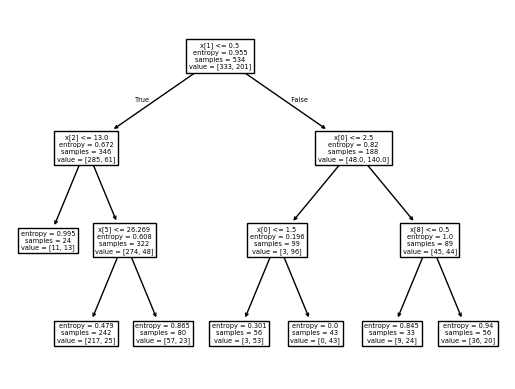

In [70]:
# Final Best Tree
plot_tree(best_cls)

**FASTER WAY FOR THE SAME PROCESS**

In [74]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    "max_depth": [8, 10, 12],
    "min_samples_split": [40, 50, 60, 70, 80],
    "min_samples_leaf": [10, 15, 20, 30],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0],
    "max_leaf_nodes": [None, 20, 30, 40, 50]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_tree = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)
print()

y_train_pred = best_tree.predict(X_train)
y_cv_pred = best_tree.predict(X_cv)
y_test_pred = best_tree.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"CV Accuracy:    {accuracy_score(y_cv, y_cv_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")

Best Parameters:
{'ccp_alpha': 0, 'criterion': 'entropy', 'max_depth': 8, 'max_leaf_nodes': None, 'min_samples_leaf': 10, 'min_samples_split': 60}

Train Accuracy: 0.8352
CV Accuracy:    0.7753
Test Accuracy:  0.8156


[Text(0.5, 0.9444444444444444, 'x[1] <= 0.5\nentropy = 0.955\nsamples = 534\nvalue = [333, 201]'),
 Text(0.2222222222222222, 0.8333333333333334, 'x[2] <= 3.5\nentropy = 0.672\nsamples = 346\nvalue = [285, 61]'),
 Text(0.3611111111111111, 0.8888888888888888, 'True  '),
 Text(0.16666666666666666, 0.7222222222222222, 'entropy = 0.779\nsamples = 13\nvalue = [3, 10]'),
 Text(0.2777777777777778, 0.7222222222222222, 'x[0] <= 1.5\nentropy = 0.618\nsamples = 333\nvalue = [282, 51]'),
 Text(0.16666666666666666, 0.6111111111111112, 'x[2] <= 27.5\nentropy = 0.885\nsamples = 66\nvalue = [46, 20]'),
 Text(0.1111111111111111, 0.5, 'entropy = 1.0\nsamples = 10\nvalue = [5, 5]'),
 Text(0.2222222222222222, 0.5, 'entropy = 0.838\nsamples = 56\nvalue = [41, 15]'),
 Text(0.3888888888888889, 0.6111111111111112, 'x[3] <= 3.0\nentropy = 0.518\nsamples = 267\nvalue = [236, 31]'),
 Text(0.3333333333333333, 0.5, 'x[2] <= 32.25\nentropy = 0.535\nsamples = 254\nvalue = [223, 31]'),
 Text(0.2222222222222222, 0.3888

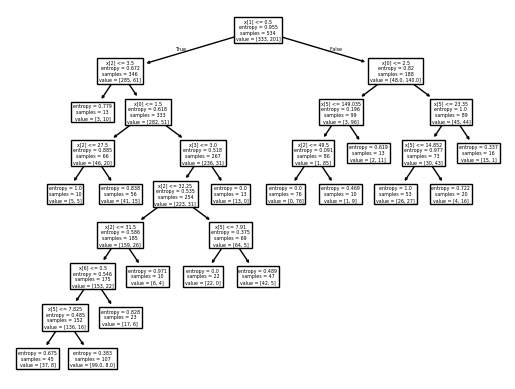

In [75]:
plot_tree(best_tree)

**Conclusion**

Manual hyperparameter tuning outperformed GridSearchCV on this dataset by achieving higher cross-validation and test accuracy while producing a simpler Decision Tree.